<a href="https://colab.research.google.com/github/gianlucamajor/eCruziDB/blob/main/eda/potential-biomaker-candidates-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Colab-**eCruzidb** Extended Data Analysis
## Potential Biomarker Candidates EDA



In [1]:
#@title Input parameters, then hit `Runtime` -> `Run all`

# Define what constitutes a "Potential Biomarker"

#@markdown 1. High Reactivity in Disease Group (Z-score > X)
disease_threshold = 3 #@param {type:"number"}
#@markdown 2. Low Reactivity in Control Group (Z-score < Y)
control_threshold = 0 #@param {type:"number"}

In [7]:
#@title Install dependencies and loading libs
%time
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.stats import zscore

if not os.path.isfile("EDA_READY"):
  print("installing eCruzidb Extend Data Analysis...")
  !pip install adjustText
  os.system("touch EDA_READY")

from adjustText import adjust_text


CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 4.77 µs


In [3]:
#@title Download data from eCruzidb
# The authority will not require after eCruzidb became open
%time
PE_json_url = "https://projetos.lbi.iq.usp.br/trypanosoma/ecruzidb/data/epitopes-data.json"
user = "ecruzidb"
password = "setulab"

response = requests.get(PE_json_url, auth=(user, password))
if response.status_code == 200:
    data = response.json()
    PEs_df = pd.DataFrame(data)
else:
    print(f"Failed to fetch data: {response.status_code}")

CPU times: user 8 µs, sys: 2 µs, total: 10 µs
Wall time: 13.4 µs


In [4]:
#@title Prepare dataframe
# List of Predicted Epitopes
# Define the list of columns for each group of patients
%time
new_group_columns = [
    'control_a', 'control_b', 'asympto_a', 'asympto_b',
    'CCC_mild_a', 'CCC_mild_b', 'CCC_severe_a', 'CCC_severe_b'
]

def join_replicates(row):
  row['control'] = row['control_a'] + row['control_b']
  row['asymptomatic'] = row['asympto_a'] + row['asympto_b']
  row['CCC_mild'] = row['CCC_mild_a'] + row['CCC_mild_b']
  row['CCC_severe'] = row['CCC_severe_a'] + row['CCC_severe_b']
  return row


# Iterate through the column names and extract values from the dictionary;
# when there is no info about group the column get 0 (zero) as a value.
for col_name in new_group_columns:
    PEs_df[col_name] = PEs_df['Number of Inserts by Group'].apply(lambda x: x.get(col_name, 0))

PEs_df = PEs_df.apply(lambda row: join_replicates(row), axis=1)

# Remove it because it is no longer needed
PEs_df = PEs_df.drop(columns=new_group_columns)

# Calculating Z-scores
PEs_df['zs-control'] = zscore(PEs_df['control'])
PEs_df['zs-asymptomatic'] = zscore(PEs_df['asymptomatic'])
PEs_df['zs-CCC_mild'] = zscore(PEs_df['CCC_mild'])
PEs_df['zs-CCC_severe'] = zscore(PEs_df['CCC_severe'])

# Adjusting dataframe
PEs_zs_df = PEs_df[['ID','Epitope', 'zs-control', 'zs-asymptomatic', 'zs-CCC_mild', 'zs-CCC_severe']].copy()
PEs_zs_df = PEs_zs_df.rename(columns={'zs-control': 'Control', 'zs-asymptomatic': 'Asymptomatic', 'zs-CCC_mild': 'CCC Mild', 'zs-CCC_severe': 'CCC Severe'})



CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 6.68 µs


The values used for Control <= 0 and Disease >= 3 threshold


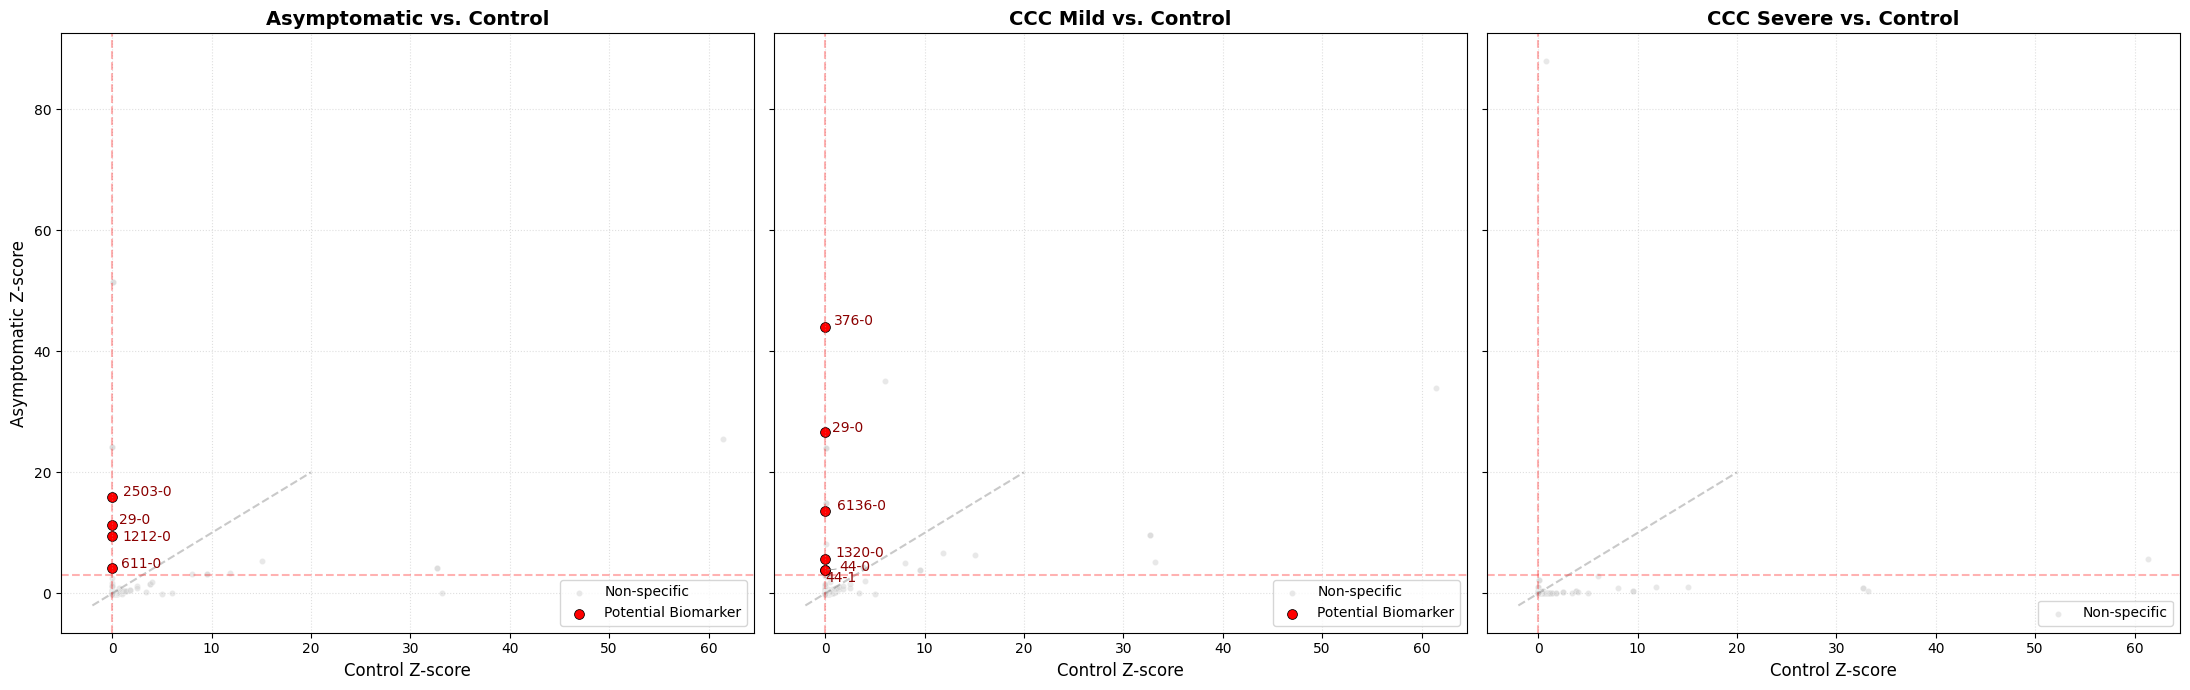

In [5]:

#@title Potential Biomarker Candidates

# Setup the figure
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True, sharey=True)

# Comparisons to plot
comparisons = [
    ('Asymptomatic', 'Asymptomatic vs. Control'),
    ('CCC Mild', 'CCC Mild vs. Control'),
    ('CCC Severe', 'CCC Severe vs. Control')
]

# Assuming 'PEs_zs_df' is your wide dataframe
for i, (group, title) in enumerate(comparisons):
    ax = axes[i]

    # 1. PLOT ALL POINTS (Background - Grey/Blue)
    # We plot everything first with low opacity so they don't distract
    sns.scatterplot(data=PEs_zs_df, x='Control', y=group,
                    ax=ax, color='lightgrey', alpha=0.5, s=20, label='Non-specific')

    # 2. FILTER POINTS (Identify Biomarkers)
    # Condition: High in current Disease Group AND Low in Control
    biomarkers = PEs_zs_df[
        (PEs_zs_df[group] >= disease_threshold) &
        (PEs_zs_df['Control'] <= control_threshold)
    ]

    # 3. PLOT BIOMARKERS (Highlight - Red)
    sns.scatterplot(data=biomarkers, x='Control', y=group,
                    ax=ax, color='red', s=50, edgecolor='black', label='Potential Biomarker')

    # 4. ADD TEXT LABELS (The IDs)
    # We loop only through the filtered 'biomarkers' dataframe
    texts = []
    for _, row in biomarkers.iterrows():
        texts.append(ax.text(row['Control'], row[group], str(row['ID']), color='darkred'))

    # This function automatically moves text around to avoid overlaps
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # 5. AESTHETICS & LINES
    # Diagonal line (x=y)
    ax.plot([-2, 20], [-2, 20], ls="--", c=".3", alpha=0.3)

    # Threshold boxes (Visual guide)
    ax.axhline(disease_threshold, color='red', linestyle='--', alpha=0.3)
    ax.axvline(control_threshold, color='red', linestyle='--', alpha=0.3)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Control Z-score', fontsize=12)
    ax.set_ylabel(f'{group} Z-score', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
print(f"The values used for Control <= {control_threshold} and Disease >= {disease_threshold} threshold")
plt.show()


In [6]:
#@title List of Potential Biomarker Candidates
potential_biomarkers_Asympt_df = PEs_zs_df[(PEs_zs_df['Asymptomatic'] >= disease_threshold) & (PEs_zs_df['Control'] <= control_threshold)]
potential_biomarkers_CCC_mild_df = PEs_zs_df[(PEs_zs_df['CCC Mild'] >= disease_threshold) & (PEs_zs_df['Control'] <= control_threshold)]
potential_biomarkers_CCC_severe_df = PEs_zs_df[(PEs_zs_df['CCC Severe'] >= disease_threshold) & (PEs_zs_df['Control'] <= control_threshold)]


potential_biomarkers = pd.concat(
     [potential_biomarkers_Asympt_df, potential_biomarkers_CCC_mild_df, potential_biomarkers_CCC_severe_df], axis=0
).drop_duplicates()

print(f"The values used for Control <= {control_threshold} and Disease >= {disease_threshold} threshold")
potential_biomarkers

The values used for Control <= 0 and Disease >= 3 threshold


,ID,Epitope,Control,Asymptomatic,CCC Mild,CCC Severe
26,29-0,GPRHVDPDHFRSTTQDAY,-0.040677,11.239130,26.740089,0.120699
655,611-0,SSLAGSDGVGLA,-0.038737,4.176952,-0.058721,-0.003274
1308,1212-0,EEVRGAAPLGKYALVNTLEGSDGHFSAG,-0.032919,9.511064,-0.054132,-0.015638
2682,2503-0,GQGSSDTPCRGLNYRFPVECGDVLFLGSDGVF,-0.030979,15.976463,-0.056426,-0.014730
41,44-0,ELPLDDDSDFVAMEQERRQLLEKDPRRNA,-0.048435,1.266284,3.819005,0.380441
42,44-1,EIAALEESMNARAQELA,-0.048435,1.266284,3.819005,0.380441
402,376-0,AAHTSTPA,-0.040677,0.201883,43.984242,0.255334
1423,1320-0,AATEKRQSVNNYTTPGDSD,-0.040677,-0.040288,5.758155,-0.016318
6514,6136-0,AMGEAGGRSWSNVVKSPHSP,-0.044556,-0.041442,13.632905,-0.016205
